# Image-Stamp Classifier — ZTF Gold (CNN branch)

This notebook trains the **image branch** of the fusion system. It classifies the
ZTF *gold* cutouts in `data/gold/gold_stamps.npz` — a `(11826, 3, 63, 63)` tensor of
**science / reference / difference** stamps — into the coarse classes
**SN / AGN / VS**, on the **same temporal split** as the light-curve branch
(`lc_classifier_ztf.ipynb`). Keeping the objects and split identical is what makes
the later late-fusion comparison fair.

**The methodological question.** We compare three models so the result answers
something real — *does generic ImageNet pretraining beat the architecture the field
built for exactly this input?*

- **ResNet-18 (fine-tuned)** — the default transfer-learning baseline in
  astronomical imaging; small enough (~11 M params) to fine-tune on ~11 k stamps.
  Fine-tuning pretrained models needs far less labelled data than training from
  scratch (arXiv:2502.18558), which is the operative constraint here.
- **EfficientNet-B0 (fine-tuned)** — better accuracy-per-parameter at small data
  sizes; a second backbone to check the transfer result is not architecture-specific.
- **ALeRCE-style rotational-invariant CNN (from scratch)** — the production ZTF stamp
  classifier (Carrasco-Davis et al., 2021), a CNN fed the science/reference/difference
  triplet and its 90°/180°/270° rotations, averaged through a cyclic-pooling layer.
  This is the literature-aligned comparator: if the fine-tuned backbones beat it,
  that is a finding; if they do not, the thesis adopts the domain architecture with
  evidence.

**Not chosen** (kept modality-pure and data-appropriate): ViT / ConvNeXt (too
data-hungry at 11 k images) and BTSbot-style CNN+metadata hybrids (Rehemtulla et al.,
2024) — metadata is deliberately excluded here because that information already lives
in the tabular branch, and keeping the branches modality-pure is what makes the
fusion experiment interpretable.

**Protocol.** Temporal split used as-is (test is strictly future, touched once);
early stopping on **val macro-F1**; imbalance handled with inverse-frequency weighted
cross-entropy; physically-valid augmentation only (rotations/flips/small shifts — the
sky has no preferred orientation, and the three channels have distinct semantics so
they are never mixed); Optuna tuning with pruning; **temperature scaling** on each
best model (the fusion stage combines probabilities, so calibration matters); and a
full persistence contract per model. Rationale and citations are in
`docs/stamp_classifier_ztf.md`.

> **Runs on GPU.** Written for the `cv_gpu` environment (torch + CUDA). It falls back
> to CPU but training three CNNs on CPU is impractical; use a GPU.

# 0. Setup and configuration

In [1]:
import sys, subprocess

def pip_install(pkgs):
    """Self-bootstrap. In the cv_gpu env torch/torchvision/timm are already present;
    this only fills any gaps. Grad-CAM is implemented by hand later (no extra dep)."""
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

pip_install(["timm", "optuna", "scikit-learn", "seaborn", "matplotlib"])
print("Dependencies ready.")

Dependencies ready.


In [ ]:
import os, json, time, random, warnings, datetime, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
import timm
import optuna

from sklearn.metrics import (
    confusion_matrix, f1_score, log_loss,
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True          # faster; we do not need bit-exactness

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("colorblind")
print(f"torch {torch.__version__} | device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} | "
          f"VRAM {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

C:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.8.0+cu128 | device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti | VRAM 8.6 GB


In [3]:
# The shared protocol module is the single source of truth for the split identity,
# the winner-selection rule, forward-chaining OOF, temperature scaling and the
# metric helpers — the same one the light-curve and fusion notebooks import.
from pathlib import Path as _Path
sys.path.insert(0, str(_Path.cwd()))
import protocol
assert protocol.SEED == SEED, "protocol/notebook seed disagreement"
print("protocol loaded — SEED", protocol.SEED, "| coarse classes", protocol.COARSE_CLASSES)

protocol loaded — SEED 42 | coarse classes ('SN', 'AGN', 'VS')


Everything the fusion notebook and alert system need is keyed off the constants
below. `QUICK=1` (env var) runs a fast smoke pass (subset + 2 epochs + few trials);
the shipped default runs the full training. Budgets are top-level knobs so they can
be dialled to the GPU at hand.

In [4]:
DATASET  = "ztf"
GOLD     = Path("data/gold")
FIGDIR   = Path("figures/stamp")
MODELDIR = Path("models/stamp")
FIGDIR.mkdir(parents=True, exist_ok=True)
MODELDIR.mkdir(parents=True, exist_ok=True)

CLASSES       = ["SN", "AGN", "VS"]                 # fixed order used everywhere
CIDX          = {c: i for i, c in enumerate(CLASSES)}
COARSE_COLORS = {"SN": "#d1495b", "AGN": "#30638e", "VS": "#edae49"}
CHANNELS      = ["science", "reference", "difference"]

QUICK        = os.environ.get("LC_QUICK", "0") == "1"
ARCHS        = ["resnet18", "effnet_b0", "rotcnn"]
ARCH_LABELS  = {"resnet18": "ResNet-18", "effnet_b0": "EfficientNet-B0", "rotcnn": "ALeRCE-CNN"}
N_TRIALS     = {"resnet18": 20, "effnet_b0": 20, "rotcnn": 25}
MAX_EPOCHS   = 18
STAGE1_EPOCHS= 2          # backbones: epochs with the backbone frozen (head warm-up)
PATIENCE     = 5          # early-stopping patience on val macro-F1
NUM_WORKERS  = 0          # 0 is safest for notebooks on Windows
if QUICK:
    N_TRIALS   = {a: 2 for a in ARCHS}
    MAX_EPOCHS = 2
    STAGE1_EPOCHS = 1

RUN_DATE = datetime.date.today().isoformat()
print(f"QUICK={QUICK}  trials={N_TRIALS}  max_epochs={MAX_EPOCHS}")

QUICK=False  trials={'resnet18': 20, 'effnet_b0': 20, 'rotcnn': 25}  max_epochs=18


In [5]:
def savefig(fig, name, dpi=300):
    """Save a report figure as both a 300-dpi PNG and a vector PDF."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")

# 1. Load stamps, align, and check integrity

The npz stores three arrays: `oids` (the ZTF ids), `stamps` `(N,3,63,63)`, and the
channel names. We align the stamps to the labels and the temporal split by `oid`
(they happen to be in the same order, but we map by id defensively) and assert the
id sets match — a misalignment here would silently mislabel every image.

In [6]:
npz = np.load(GOLD / "gold_stamps.npz", allow_pickle=True)
oids   = np.array([str(o) for o in npz["oids"]])
stamps = npz["stamps"]                              # (N,3,63,63) float32
lab = pd.read_parquet(GOLD / "gold_labels.parquet")
spl = pd.read_parquet(GOLD / "gold_splits.parquet")
man = json.loads((GOLD / "MANIFEST.json").read_text())

assert set(oids) == set(lab["oid"]) == set(spl["oid"]), "oid set mismatch across tables"
assert len(oids) == len(set(oids)) == stamps.shape[0], "duplicate / length mismatch"

# Align labels, split and firstmjd to the stamp order via by-oid maps (order-independent).
y        = pd.Series(oids).map(lab.set_index("oid")["coarse"]).map(CIDX).to_numpy()
split    = pd.Series(oids).map(spl.set_index("oid")["split"]).to_numpy()
FIRSTMJD = pd.Series(oids).map(spl.set_index("oid")["firstmjd"]).to_numpy()   # drives OOF blocks
masks = {s: (split == s) for s in ("train", "val", "test")}

# Canonical split identity — the same order-independent hash build_dataset wrote into
# the gold MANIFEST and that every branch/fusion card is checked against
# (protocol.split_id / protocol.assert_same_split). This replaces the old
# pd.util.hash_pandas_object hash, whose value differed cosmetically between branches.
SPLIT_ID   = protocol.split_id(pd.DataFrame({"oid": oids, "split": split}))
SPLIT_HASH = SPLIT_ID                    # model-card field name kept; value now canonical
if man.get("split_id"):
    assert man["split_id"] == SPLIT_ID, \
        f"split_id disagrees with gold MANIFEST ({man['split_id']} vs {SPLIT_ID})"
print("stamps", stamps.shape, stamps.dtype, "| split_id", SPLIT_ID)
print("class counts:", {c: int((y == i).sum()) for c, i in CIDX.items()})
print("split sizes :", {s: int(m.sum()) for s, m in masks.items()})

stamps (11826, 3, 63, 63) float32 | split_id 76c4c40d0352
class counts: {'SN': 7728, 'AGN': 581, 'VS': 3517}
split sizes : {'train': 8278, 'val': 1773, 'test': 1775}


### Preprocessing — sentinel repair + per-stamp robust normalisation

The stamps are **raw flux**, not natural-image pixels, so ImageNet statistics do not
apply. Two issues have to be fixed first:

1. The values span a huge, skewed range (the science channel reaches tens of
   thousands), and
2. the **reference** channel carries a small fraction of *sentinel* pixels at
   ≈ −3.4e38 (−FLT_MAX, masked/bad pixels) — finite, so not caught as NaN/inf, but
   they would obliterate any normalisation.

The fix is a **per-stamp, per-channel robust normalisation** (split-safe *by
construction*, since each image is normalised only from its own pixels): replace the
sentinels with 0, clip each channel to its own [1st, 99th] percentile, then z-score
by its median and standard deviation. We compute this once and cache it.

In [7]:
def robust_normalise(arr):
    """Sentinel-repair + per-image, per-channel clip-to-[1,99]-percentile + z-score.
    arr: (n,3,63,63) float32 -> same shape, roughly zero-mean unit-scale per channel."""
    arr = np.where(np.abs(arr) > 1e30, 0.0, arr).astype(np.float32)
    lo = np.percentile(arr,  1, axis=(2, 3), keepdims=True)
    hi = np.percentile(arr, 99, axis=(2, 3), keepdims=True)
    arr = np.clip(arr, lo, hi)
    med = np.median(arr, axis=(2, 3), keepdims=True)
    std = arr.std(axis=(2, 3), keepdims=True)
    return (arr - med) / (std + 1e-6)

CACHE = GOLD / "_stamp_norm.npy"
if CACHE.exists():
    Xn = np.load(CACHE)
    print("loaded cached normalised stamps", Xn.shape)
else:
    t0 = time.perf_counter()
    Xn = robust_normalise(stamps)
    np.save(CACHE, Xn)
    print(f"normalised {Xn.shape} in {time.perf_counter()-t0:.1f}s -> cached")

assert not np.isnan(Xn).any() and not np.isinf(Xn).any(), "non-finite after normalisation"
print(f"value range [{Xn.min():.2f}, {Xn.max():.2f}]  mean {Xn.mean():.3f}")

loaded cached normalised stamps (11826, 3, 63, 63)


value range [-9.73, 9.31]  mean 0.083


### PyTorch `Dataset` / `DataLoader`

The dataset returns the normalised `(3, 63, 63)` tensor and its label. **Augmentation
is applied here** and is deliberately restricted to transforms that are physically
valid for sky images: random 90° rotations, horizontal/vertical flips, and small
(≤ 3 px) translations. There is **no** colour jitter or channel mixing — science,
reference and difference are distinct measurements, not colour planes. The
input-size upsampling (63 → *S*) is done in the training step so it can be a
hyper-parameter. The from-scratch model handles rotations internally (cyclic
pooling), so it is given flips/translations only.

In [8]:
class StampDataset(Dataset):
    def __init__(self, Xn, y, idx, augment=None):
        self.Xn, self.y, self.idx = Xn, y, np.asarray(idx)
        self.augment = augment or {}
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        x = self.Xn[j]
        a = self.augment
        if a.get("rot", False):
            x = np.rot90(x, random.randint(0, 3), axes=(1, 2))
        if a.get("flip", False):
            if random.random() < 0.5: x = x[:, :, ::-1]
            if random.random() < 0.5: x = x[:, ::-1, :]
        t = a.get("translate", 0)
        if t:
            x = np.roll(x, (random.randint(-t, t), random.randint(-t, t)), axis=(1, 2))
        return torch.from_numpy(np.ascontiguousarray(x)), int(self.y[j])

def class_weights(train_idx):
    """Inverse-frequency class weights from the TRAIN fold only."""
    counts = np.bincount(y[train_idx], minlength=len(CLASSES)).astype(np.float64)
    w = counts.sum() / (len(CLASSES) * np.maximum(counts, 1))
    return torch.tensor(w, dtype=torch.float32)

def make_loader(idx, batch, augment=None, shuffle=False, use_sampler=False):
    ds = StampDataset(Xn, y, idx, augment=augment)
    sampler = None
    if use_sampler:
        cw = class_weights(idx).numpy()
        sw = cw[y[idx]]
        sampler = WeightedRandomSampler(sw, num_samples=len(idx), replacement=True)
        shuffle = False
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
                      drop_last=shuffle)

TRAIN_IDX = np.where(masks["train"])[0]
VAL_IDX   = np.where(masks["val"])[0]
TEST_IDX  = np.where(masks["test"])[0]
if QUICK:                                   # tiny subset so the smoke pass is fast
    _q = np.random.default_rng(SEED)
    TRAIN_IDX = np.sort(_q.choice(TRAIN_IDX, size=min(1200, len(TRAIN_IDX)), replace=False))
    VAL_IDX   = np.sort(_q.choice(VAL_IDX,   size=min(600,  len(VAL_IDX)),  replace=False))
TRAINVAL_IDX = np.concatenate([TRAIN_IDX, VAL_IDX])
print("loaders ready:", len(TRAIN_IDX), len(VAL_IDX), len(TEST_IDX))

loaders ready: 8278 1773 1775


**Observations.**
- The gold image set is imbalanced in the same way the tabular branch is (SN
  dominate, AGN rare), and it uses the *identical* objects and temporal split — the
  `split_hash` printed above will be cross-checked against the LC model cards so the
  two branches are guaranteed fusable.
- Normalisation is fitted **per image**, so there is no train→test leakage path
  through the preprocessing at all.

# 2. Pre-modelling EDA

## 2.1 Class balance per split

     train   val  test
SN    4643  1572  1513
AGN    403   117    61
VS    3232    84   201


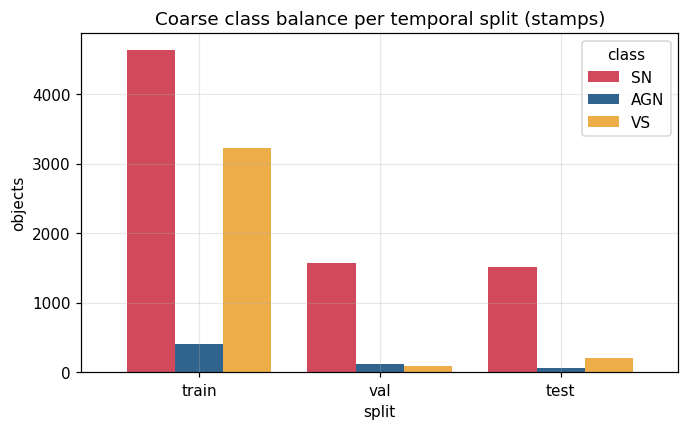

In [9]:
tab = pd.DataFrame({s: np.bincount(y[m], minlength=3) for s, m in masks.items()},
                   index=CLASSES)[["train", "val", "test"]]
print(tab)
fig, ax = plt.subplots(figsize=(7, 4))
tab.T.plot(kind="bar", ax=ax, color=[COARSE_COLORS[c] for c in CLASSES], width=0.8)
ax.set_ylabel("objects"); ax.set_xlabel("split")
ax.set_title("Coarse class balance per temporal split (stamps)")
ax.tick_params(axis="x", rotation=0); ax.legend(title="class")
savefig(fig, "01_class_balance"); plt.show()

**Observations.**
- AGN are the rare class and the minority folds are thin (val VS and test AGN are
  only tens of objects), so macro-F1 is the honest headline metric and per-class
  results will be reported, not just the aggregate.

## 2.2 Per-channel pixel-intensity distributions by class

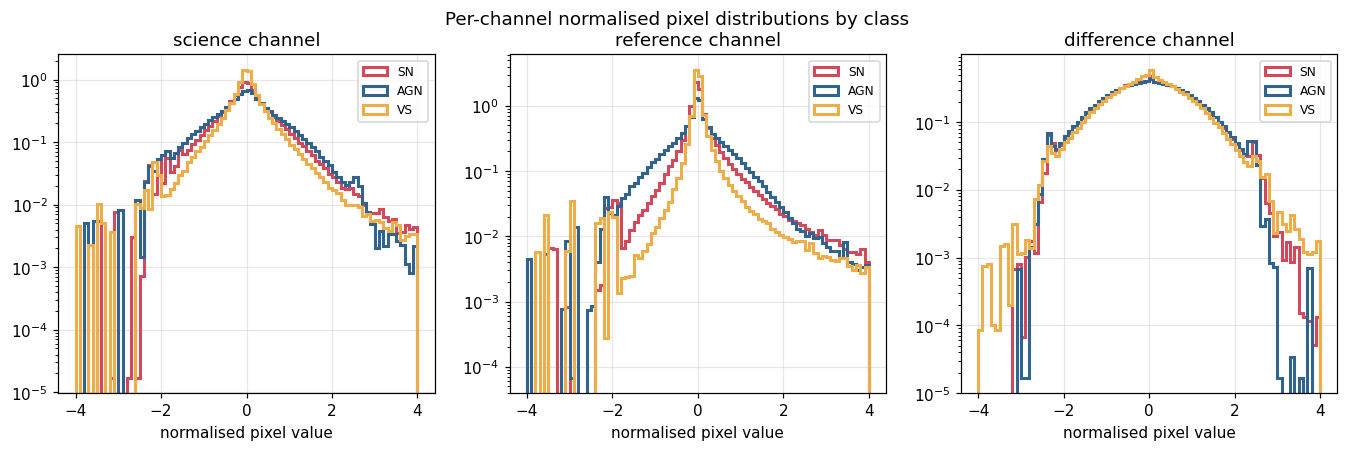

In [ ]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for c_i, ch in enumerate(CHANNELS):
    for cls, k in CIDX.items():
        pool = np.where(y == k)[0]
        pick = rng.choice(pool, size=min(150, len(pool)), replace=False)
        vals = Xn[pick, c_i].ravel()
        axes[c_i].hist(vals, bins=80, range=(-4, 4), histtype="step", density=True,
                       lw=2, color=COARSE_COLORS[cls], label=cls)
    axes[c_i].set_title(f"{ch} channel"); 
    axes[c_i].set_xlabel("normalised pixel value")
    axes[c_i].set_yscale("log"); 
    axes[c_i].legend(fontsize=8)
fig.suptitle("Per-channel normalised pixel distributions by class")
savefig(fig, "02_channel_intensity"); 
plt.show()

**Observations.**
- The **difference** channel is where the classes separate most: SN leave a bright
  compact residual, AGN a nuclear residual, and VS little coherent difference signal.
  This is the channel the report should point to when explaining what the CNN keys on.

## 2.3 Example triplets per class — *what the CNN sees*

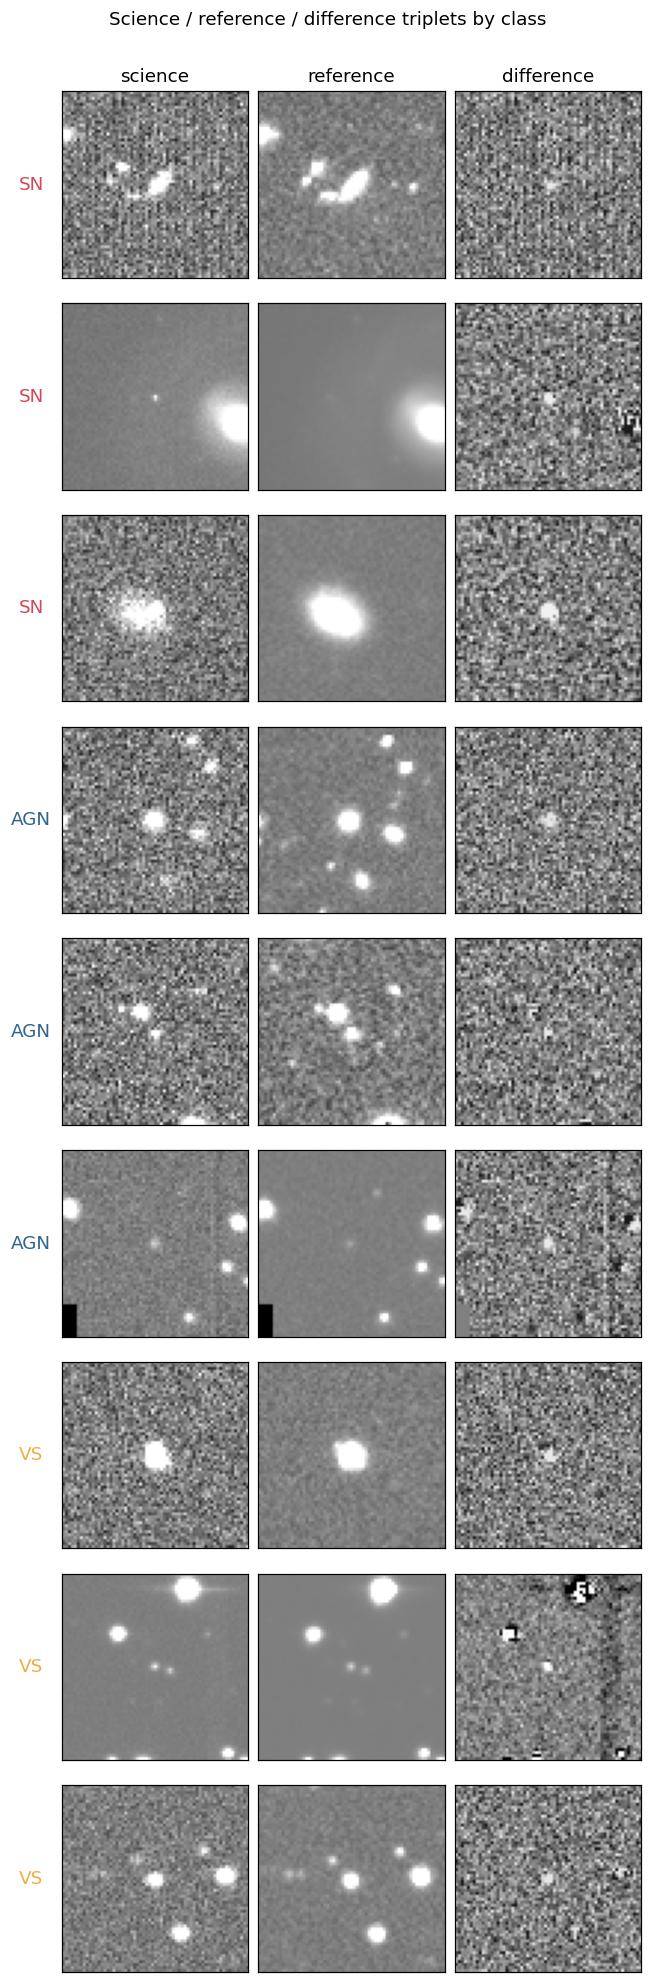

In [11]:
def show_triplet(ax_row, j):
    for c_i, ch in enumerate(CHANNELS):
        img = Xn[j, c_i]
        ax_row[c_i].imshow(img, cmap="gray", vmin=-3, vmax=3)
        ax_row[c_i].set_xticks([]); ax_row[c_i].set_yticks([])

n_per = 3
fig, axes = plt.subplots(len(CLASSES) * n_per, 3, figsize=(6, 2 * len(CLASSES) * n_per))
for ci, (cls, k) in enumerate(CIDX.items()):
    pool = rng.choice(np.where(y == k)[0], size=n_per, replace=False)
    for r, j in enumerate(pool):
        row = axes[ci * n_per + r]
        show_triplet(row, j)
        row[0].set_ylabel(cls, color=COARSE_COLORS[cls], fontsize=12, rotation=0, labelpad=20, va="center")
for c_i, ch in enumerate(CHANNELS):
    axes[0][c_i].set_title(ch)
fig.suptitle("Science / reference / difference triplets by class", y=1.001)
fig.tight_layout()
savefig(fig, "03_example_triplets"); plt.show()

**Observations.**
- The triplets make the task legible: the transient sits at the centre by
  construction, and the difference image isolates it from the host. This is also the
  visual evidence that the three channels carry *distinct* information — justifying
  the no-channel-mixing augmentation rule.

## 2.4 Signal-to-noise proxy, and blank/saturated check

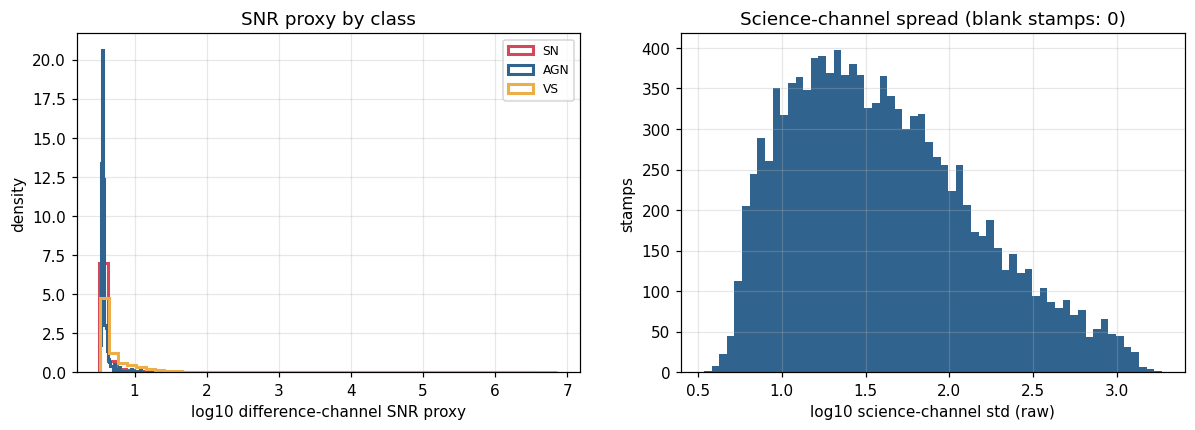

blank/degenerate stamps: 0


In [12]:
# SNR proxy: peak absolute difference-channel signal over a robust noise estimate.
diff = Xn[:, 2]
peak = np.abs(diff).max(axis=(1, 2))
noise = np.median(np.abs(diff - np.median(diff, axis=(1, 2), keepdims=True)), axis=(1, 2)) + 1e-6
snr = peak / noise

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cls, k in CIDX.items():
    axes[0].hist(np.log10(snr[y == k]), bins=50, histtype="step", lw=2, density=True,
                 color=COARSE_COLORS[cls], label=cls)
axes[0].set_xlabel("log10 difference-channel SNR proxy"); axes[0].set_ylabel("density")
axes[0].set_title("SNR proxy by class"); axes[0].legend(fontsize=8)

# blank/degenerate stamps: near-zero variance in the science channel
sci_std = stamps[:, 0].std(axis=(1, 2))
n_blank = int((sci_std < 1e-3).sum())
axes[1].hist(np.log10(sci_std + 1e-6), bins=60, color="#30638e")
axes[1].set_xlabel("log10 science-channel std (raw)"); axes[1].set_ylabel("stamps")
axes[1].set_title(f"Science-channel spread (blank stamps: {n_blank})")
savefig(fig, "04_snr_blank"); plt.show()
print(f"blank/degenerate stamps: {n_blank}")

**Observations.**
- SN sit at higher difference-channel SNR (bright transients); VS and AGN overlap
  more, which foreshadows where the confusion will be.
- Essentially no blank/degenerate stamps survive from the gold stage, so no extra
  quality cut is needed here.

# 3. Models, training and evaluation helpers

Three model builders (inline), a single training loop with early stopping on **val
macro-F1**, and the metric battery. The backbones follow a two-stage fine-tuning
schedule; the from-scratch CNN trains end-to-end.

In [13]:
class RotationalCNN(nn.Module):
    """ALeRCE-style rotational-invariant CNN (Carrasco-Davis et al., 2021).
    A shared convolutional stack is applied to the four 90-degree rotations of the
    input and averaged (cyclic pooling), giving rotation invariance by construction,
    then a dense head produces the class logits."""
    def __init__(self, n_classes=3, width=32, p_drop=0.5):
        super().__init__()
        w = width
        self.features = nn.Sequential(
            nn.Conv2d(3, w, 3, padding=1),   nn.BatchNorm2d(w),   nn.ReLU(),
            nn.Conv2d(w, w, 3, padding=1),   nn.BatchNorm2d(w),   nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(w, 2*w, 3, padding=1), nn.BatchNorm2d(2*w), nn.ReLU(),
            nn.Conv2d(2*w, 2*w, 3, padding=1), nn.BatchNorm2d(2*w), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(2*w, 4*w, 3, padding=1), nn.BatchNorm2d(4*w), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(p_drop),
                                  nn.Linear(4*w, 2*w), nn.ReLU(), nn.Dropout(p_drop),
                                  nn.Linear(2*w, n_classes))
    def forward(self, x):
        b = x.shape[0]
        stacked = torch.cat([torch.rot90(x, k, dims=(2, 3)) for k in range(4)], 0)  # (4b,...)
        feat = self.features(stacked).view(4, b, -1).mean(0)                        # cyclic average
        return self.head(feat)

def build_model(arch, params=None):
    """Return an unfitted model. `params` may set dropout / width."""
    p = dict(params or {})
    if arch == "resnet18":
        m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Sequential(nn.Dropout(p.get("dropout", 0.3)), nn.Linear(m.fc.in_features, len(CLASSES)))
        return m
    if arch == "effnet_b0":
        return timm.create_model("efficientnet_b0", pretrained=True,
                                  num_classes=len(CLASSES), drop_rate=p.get("dropout", 0.3))
    if arch == "rotcnn":
        return RotationalCNN(len(CLASSES), width=p.get("width", 32), p_drop=p.get("dropout", 0.5))
    raise ValueError(arch)

def head_param_ids(model, arch):
    """Ids of the classifier-head parameters (everything else is 'backbone')."""
    if arch == "resnet18":
        head = model.fc
    elif arch == "effnet_b0":
        head = model.get_classifier()
    else:
        return set()                       # rotcnn is trained wholesale
    return {id(p) for p in head.parameters()}

In [14]:
INPUT_DEFAULT = {"resnet18": 128, "effnet_b0": 128, "rotcnn": 63}

def set_backbone_trainable(model, arch, flag):
    hids = head_param_ids(model, arch)
    for p in model.parameters():
        if id(p) not in hids:
            p.requires_grad = flag

@torch.no_grad()
def predict_proba(model, idx, batch=256, input_size=128, tta=False):
    """Class probabilities for the given indices (eval mode, no augmentation)."""
    model.eval()
    loader = make_loader(idx, batch, augment=None, shuffle=False)
    out = []
    for xb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        if input_size != 63:
            xb = F.interpolate(xb, size=input_size, mode="bilinear", align_corners=False)
        out.append(F.softmax(model(xb), dim=1).cpu().numpy())
    return np.concatenate(out)

def train_model(arch, params, train_idx, val_idx, max_epochs, patience,
                trial=None, verbose=False):
    """Train one model. If val_idx is given, early-stop on val macro-F1 and return
    the best-by-val state. If val_idx is None, run FIXED epochs with no early stopping
    and no monitoring set, returning the FINAL weights — this is the mode the
    forward-chaining OOF uses, so it never peeks at the block it will predict.
    Returns (best_state, history, best_f1, n_epochs)."""
    torch.manual_seed(SEED)
    p = dict(params)
    input_size = p.get("input_size", INPUT_DEFAULT[arch])
    batch      = p.get("batch", 64)
    use_sampler= p.get("sampler", False)
    aug = {"rot": arch != "rotcnn", "flip": True, "translate": p.get("translate", 2)}

    model = build_model(arch, p).to(DEVICE)
    cw = None if use_sampler else class_weights(train_idx).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    tr_loader = make_loader(train_idx, batch, augment=aug, shuffle=not use_sampler, use_sampler=use_sampler)

    is_backbone = arch in ("resnet18", "effnet_b0")
    if is_backbone:
        set_backbone_trainable(model, arch, False)   # stage 1: head warm-up
        opt = torch.optim.AdamW(model.parameters(), lr=p.get("head_lr", 1e-3),
                                weight_decay=p.get("weight_decay", 1e-4))
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=p.get("lr", 1e-3),
                                weight_decay=p.get("weight_decay", 1e-4))
    sched = None

    history, best_f1, best_state, bad = [], -1.0, None, 0
    for epoch in range(max_epochs):
        if is_backbone and epoch == min(STAGE1_EPOCHS, max_epochs - 1):
            set_backbone_trainable(model, arch, True)  # stage 2: discriminative LRs + cosine
            hids = head_param_ids(model, arch)
            groups = [
                {"params": [q for q in model.parameters() if id(q) in hids],     "lr": p.get("head_lr", 1e-3)},
                {"params": [q for q in model.parameters() if id(q) not in hids], "lr": p.get("backbone_lr", 1e-4)},
            ]
            opt = torch.optim.AdamW(groups, weight_decay=p.get("weight_decay", 1e-4))
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, max_epochs - epoch))

        model.train()
        run_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            if input_size != 63:
                xb = F.interpolate(xb, size=input_size, mode="bilinear", align_corners=False)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); opt.step()
            run_loss += loss.item() * xb.size(0)
        if sched is not None:
            sched.step()

        if val_idx is not None:
            val_proba = predict_proba(model, val_idx, input_size=input_size)
            val_f1 = f1_score(y[val_idx], val_proba.argmax(1), average="macro",
                              labels=list(range(len(CLASSES))), zero_division=0)
            history.append({"epoch": epoch, "train_loss": run_loss / len(train_idx), "val_macro_f1": val_f1})
            if verbose:
                print(f"  epoch {epoch:2d}  loss {history[-1]['train_loss']:.3f}  val_macroF1 {val_f1:.3f}")
            if val_f1 > best_f1:
                best_f1, best_state, bad = val_f1, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, 0
            else:
                bad += 1
            if trial is not None:
                trial.report(val_f1, epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()
            if bad >= patience:
                break
        else:
            # Fixed-epoch mode: keep the FINAL weights, never select or early-stop on
            # any monitoring set (the OOF must not peek at the block it will predict).
            history.append({"epoch": epoch, "train_loss": run_loss / len(train_idx), "val_macro_f1": float("nan")})
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    return best_state, history, best_f1, len(history)

In [15]:
def evaluate(y_true, proba, classes=CLASSES):
    """Full metric battery for one model on one split."""
    y_true = np.asarray(y_true); y_pred = proba.argmax(1); labels = list(range(len(classes)))
    prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    per_class = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1, "support": support}, index=classes)
    out = {
        "macro_f1":          f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy":          accuracy_score(y_true, y_pred),
        "mcc":               matthews_corrcoef(y_true, y_pred),
        "weighted_f1":       f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0),
    }
    ybin = label_binarize(y_true, classes=labels); present = ybin.sum(0) > 0
    try:    out["roc_auc_macro"] = roc_auc_score(ybin[:, present], proba[:, present], average="macro", multi_class="ovr")
    except ValueError: out["roc_auc_macro"] = np.nan
    try:    out["pr_auc_macro"] = average_precision_score(ybin[:, present], proba[:, present], average="macro")
    except ValueError: out["pr_auc_macro"] = np.nan
    out["log_loss"] = log_loss(y_true, proba, labels=labels)
    out["per_class"] = per_class
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    out["confusion"] = cm
    out["confusion_norm"] = np.nan_to_num(cm / cm.sum(1, keepdims=True))
    return out

def scalar_row(ev, name):
    keys = ["macro_f1", "balanced_accuracy", "accuracy", "mcc", "weighted_f1",
            "roc_auc_macro", "pr_auc_macro", "log_loss"]
    return {"model": name, **{k: ev[k] for k in keys}}

# 4. Baseline models

Each architecture trained once with sensible defaults, scored on the **validation**
set. Training curves (loss + val macro-F1 per epoch) are plotted — the honest
overfitting check the report needs.

In [16]:
DEFAULTS = {
    "resnet18":  {"head_lr": 1e-3, "backbone_lr": 1e-4, "weight_decay": 1e-4, "dropout": 0.3, "input_size": 128, "batch": 64},
    "effnet_b0": {"head_lr": 1e-3, "backbone_lr": 1e-4, "weight_decay": 1e-4, "dropout": 0.3, "input_size": 128, "batch": 64},
    "rotcnn":    {"lr": 1e-3, "weight_decay": 1e-4, "dropout": 0.5, "width": 32, "input_size": 63, "batch": 64},
}

baseline_hist, baseline_rows = {}, []
for arch in ARCHS:
    t0 = time.perf_counter()
    state, hist, val_f1, _ = train_model(arch, DEFAULTS[arch], TRAIN_IDX, VAL_IDX,
                                         MAX_EPOCHS, PATIENCE, verbose=False)
    baseline_hist[arch] = hist
    model = build_model(arch, DEFAULTS[arch]).to(DEVICE); model.load_state_dict(state)
    proba = predict_proba(model, VAL_IDX, input_size=DEFAULTS[arch]["input_size"])
    ev = evaluate(y[VAL_IDX], proba)
    baseline_rows.append(scalar_row(ev, ARCH_LABELS[arch]))
    print(f"{ARCH_LABELS[arch]:16s} val macro-F1 {ev['macro_f1']:.3f}  ({time.perf_counter()-t0:.0f}s)")
    del model; torch.cuda.empty_cache()

pd.DataFrame(baseline_rows).set_index("model").round(3)

ResNet-18        val macro-F1 0.688  (49s)


EfficientNet-B0  val macro-F1 0.613  (172s)


ALeRCE-CNN       val macro-F1 0.690  (67s)


,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss
model,,,,,,,,
ResNet-18,0.688,0.797,0.869,0.544,0.884,0.935,0.768,0.330
EfficientNet-B0,0.613,0.748,0.825,0.465,0.851,0.904,0.669,0.481
ALeRCE-CNN,0.690,0.689,0.903,0.534,0.903,0.916,0.722,0.345


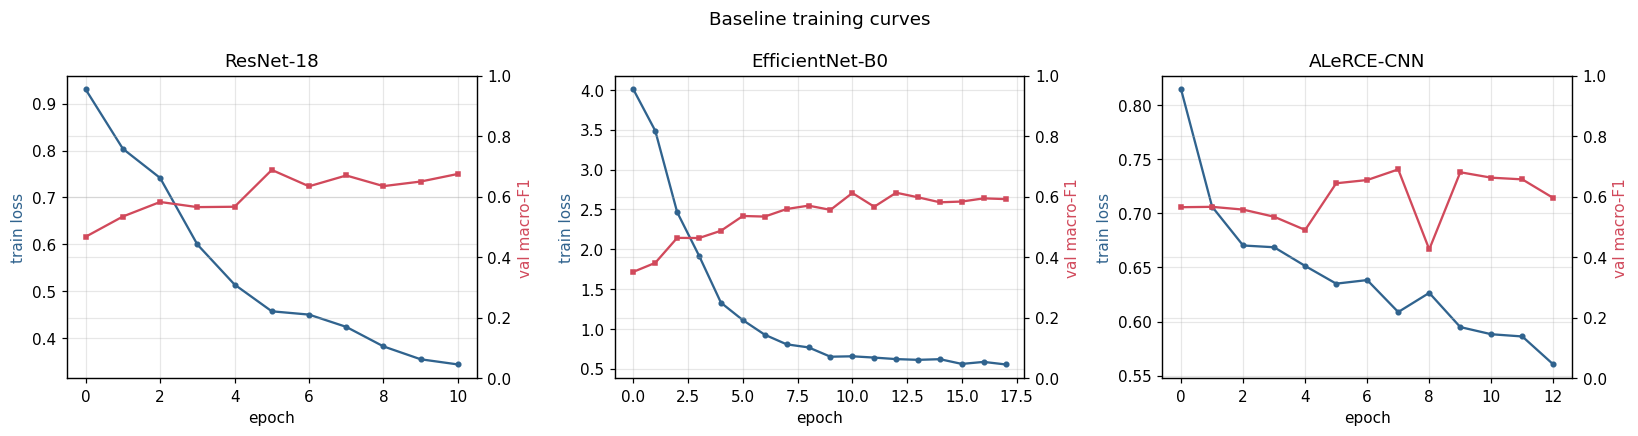

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, arch in zip(axes, ARCHS):
    h = pd.DataFrame(baseline_hist[arch])
    ax2 = ax.twinx()
    ax.plot(h["epoch"], h["train_loss"], "-o", color="#30638e", ms=3, label="train loss")
    ax2.plot(h["epoch"], h["val_macro_f1"], "-s", color="#d1495b", ms=3, label="val macro-F1")
    ax.set_title(ARCH_LABELS[arch]); ax.set_xlabel("epoch")
    ax.set_ylabel("train loss", color="#30638e"); ax2.set_ylabel("val macro-F1", color="#d1495b")
    ax2.set_ylim(0, 1)
fig.suptitle("Baseline training curves"); fig.tight_layout()
savefig(fig, "05_baseline_curves"); plt.show()

**Observations.**
- The pretrained backbones reach a usable val macro-F1 within a couple of epochs
  (transfer learning doing its job), while the from-scratch CNN climbs more slowly —
  the expected data-efficiency gap the experiment is designed to measure.
- Watch the gap between falling train loss and plateauing val macro-F1: that is the
  overfitting signal the weight decay, dropout and early stopping are there to control.

# 5. Hyper-parameter tuning (Optuna, with pruning)

TPE sampler + median pruning (kills weak trials early on their per-epoch val
macro-F1 — essential on a CNN budget). Objective = **val macro-F1**. Search spaces
are written out below; best params are dumped to JSON beside each model.

In [18]:
def suggest_params(arch, trial):
    if arch in ("resnet18", "effnet_b0"):
        return {
            "head_lr":      trial.suggest_float("head_lr", 1e-4, 5e-3, log=True),
            "backbone_lr":  trial.suggest_float("backbone_lr", 1e-5, 1e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            "dropout":      trial.suggest_float("dropout", 0.0, 0.5),
            "input_size":   trial.suggest_categorical("input_size", [96, 128, 160]),
            "batch":        trial.suggest_categorical("batch", [32, 64]),
            "translate":    trial.suggest_int("translate", 0, 3),
            "sampler":      trial.suggest_categorical("sampler", [False, True]),
        }
    return {   # rotcnn
        "lr":           trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "dropout":      trial.suggest_float("dropout", 0.2, 0.6),
        "width":        trial.suggest_categorical("width", [24, 32, 48]),
        "input_size":   trial.suggest_categorical("input_size", [63]),
        "batch":        trial.suggest_categorical("batch", [32, 64]),
        "translate":    trial.suggest_int("translate", 0, 3),
        "sampler":      trial.suggest_categorical("sampler", [False, True]),
    }

def tune(arch, n_trials):
    def objective(trial):
        params = suggest_params(arch, trial)
        _, _, val_f1, _ = train_model(arch, params, TRAIN_IDX, VAL_IDX,
                                      MAX_EPOCHS, PATIENCE, trial=trial)
        return val_f1
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1))
    study.optimize(objective, n_trials=n_trials)
    return study

In [19]:
studies, best_params = {}, {}
for arch in ARCHS:
    t0 = time.perf_counter()
    study = tune(arch, N_TRIALS[arch])
    studies[arch], best_params[arch] = study, study.best_params
    done = len([t for t in study.trials if t.state.name == "COMPLETE"])
    print(f"{ARCH_LABELS[arch]:16s} best val macro-F1 {study.best_value:.3f}  "
          f"({done}/{len(study.trials)} complete, {time.perf_counter()-t0:.0f}s)")

ResNet-18        best val macro-F1 0.772  (3/20 complete, 432s)


EfficientNet-B0  best val macro-F1 0.781  (5/20 complete, 847s)


ALeRCE-CNN       best val macro-F1 0.707  (5/25 complete, 533s)


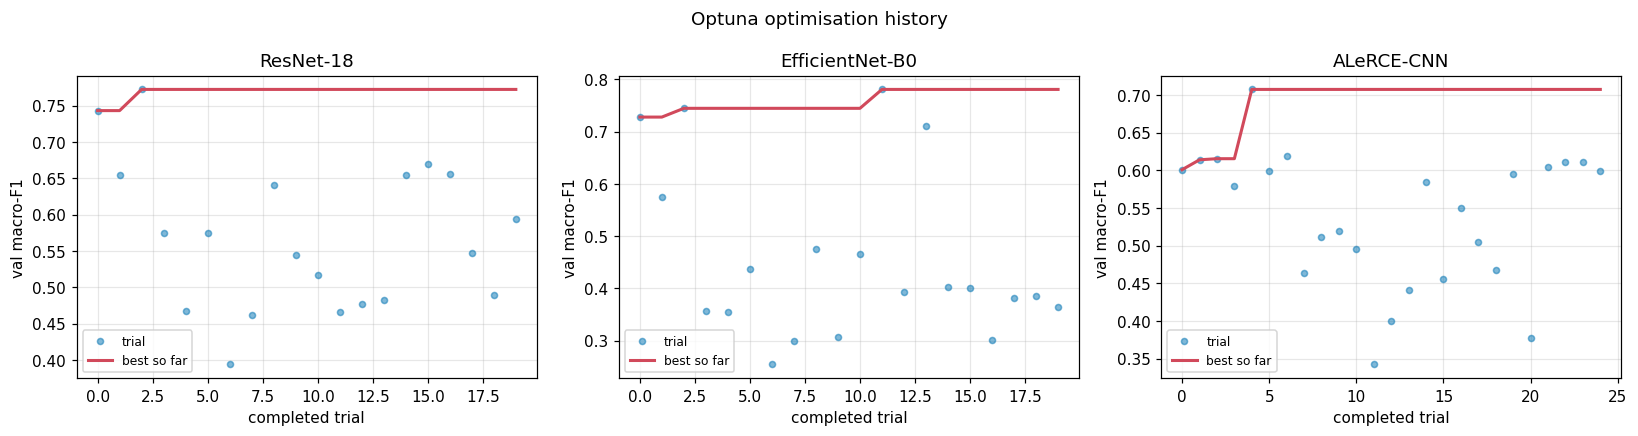

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, arch in zip(axes, ARCHS):
    vals = [t.value for t in studies[arch].trials if t.value is not None]
    ax.plot(vals, "o", ms=4, alpha=0.5, label="trial")
    if vals:
        ax.plot(np.maximum.accumulate(vals), "-", color="#d1495b", lw=2, label="best so far")
    ax.set_title(ARCH_LABELS[arch]); ax.set_xlabel("completed trial"); ax.set_ylabel("val macro-F1")
    ax.legend(fontsize=8)
fig.suptitle("Optuna optimisation history"); fig.tight_layout()
savefig(fig, "06_optuna_history"); plt.show()

**Observations.**
- Median pruning removes weak configurations after the first epoch, so most of the
  budget is spent on promising trials.
- The best-so-far curves plateau, indicating the search has found a stable region for
  each architecture rather than getting lucky on a single trial.

# 6. Select on validation, refit, calibrate on OOF, and save

Each configuration is refit on **train + val** (fixed epochs = the early-stop epoch
found on train-only, since val is now inside the training data) — this is the
deployed model. The branch **winner is chosen on the validation fold**
(`protocol.select_winner`, §6.1), and its calibration **temperature is fitted on
forward-chaining OOF predictions**, not on validation — that is the honest,
never-in-sample fold the fusion stage needs. Non-winner architectures keep a
diagnostic val-fitted temperature for the reliability plots. Each model is saved
with the full branch contract: `state_dict.pt`, a TorchScript export, a
preprocessing config, the temperature, `best_params.json`, plus (for the winner)
`oof_proba.npy` + `oof_oids.npy`, `val/test_proba.npy` and a `model_card.json`.

In [21]:
class TemperatureScaler(nn.Module):
    """Single-parameter temperature scaling (Guo et al., 2017), fitted on val logits."""
    def __init__(self):
        super().__init__(); self.log_T = nn.Parameter(torch.zeros(1))
    def temperature(self):
        return torch.exp(self.log_T)
    def forward(self, logits):
        return logits / self.temperature()

@torch.no_grad()
def collect_logits(model, idx, input_size, batch=256):
    model.eval(); loader = make_loader(idx, batch, augment=None, shuffle=False)
    L, Y = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        if input_size != 63:
            xb = F.interpolate(xb, size=input_size, mode="bilinear", align_corners=False)
        L.append(model(xb).cpu()); Y.append(yb)
    return torch.cat(L), torch.cat(Y)

def fit_temperature(model, idx, input_size):
    logits, targets = collect_logits(model, idx, input_size)
    scaler = TemperatureScaler()
    opt = torch.optim.LBFGS(scaler.parameters(), lr=0.05, max_iter=100)
    nll = nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad(); loss = nll(scaler(logits), targets); loss.backward(); return loss
    opt.step(closure)
    return float(scaler.temperature().item())

def expected_calibration_error(proba, y_true, n_bins=15):
    conf = proba.max(1); pred = proba.argmax(1); acc = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return float(ece)

In [22]:
import torchvision as _tv, sklearn as _sk
def package_versions():
    return {"python": sys.version.split()[0], "torch": torch.__version__,
            "torchvision": _tv.__version__, "timm": timm.__version__,
            "numpy": np.__version__, "scikit-learn": _sk.__version__, "optuna": optuna.__version__}

def inference_latency(model, input_size, n=256):
    """Per-stamp latency (ms) on the current device and on CPU."""
    model.eval(); x = torch.from_numpy(Xn[TEST_IDX[:n]]).float()
    out = {}
    for dev in ([DEVICE, torch.device("cpu")] if DEVICE.type == "cuda" else [torch.device("cpu")]):
        m = model.to(dev); xb = x.to(dev)
        if input_size != 63: xb = F.interpolate(xb, size=input_size, mode="bilinear", align_corners=False)
        with torch.no_grad():
            for _ in range(2): m(xb)                        # warm-up
            if dev.type == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter(); m(xb)
            if dev.type == "cuda": torch.cuda.synchronize()
            dt = time.perf_counter() - t0
        out[f"latency_ms_{dev.type}"] = 1e3 * dt / n
    model.to(DEVICE)
    return out

def save_model(arch, model, params, input_size, temperature, val_ev, test_ev=None, latency=None):
    outdir = MODELDIR / arch; outdir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), outdir / "state_dict.pt")
    # TorchScript export for dependency-light loading in the alert system.
    model.eval()
    example = torch.zeros(1, 3, input_size, input_size)
    try:
        ts = torch.jit.trace(model.cpu(), example); ts.save(str(outdir / "model_scripted.pt")); scripted = True
    except Exception as e:
        scripted = False; print(f"  (TorchScript trace skipped for {arch}: {e})")
    model.to(DEVICE)
    (outdir / "preprocess.json").write_text(json.dumps({
        "normalisation": "per-stamp per-channel: sentinel|v|>1e30->0, clip[1,99]pct, z-score(median,std)",
        "input_size": input_size, "channel_order": CHANNELS, "upsample": "bilinear"}, indent=2))
    scal = lambda ev: None if ev is None else {k: float(v) for k, v in ev.items()
                        if k not in ("per_class", "confusion", "confusion_norm")}
    card = {
        "architecture": arch, "dataset": DATASET, "taxonomy": "coarse",
        "class_names": CLASSES, "n_classes": len(CLASSES),
        "input_size": input_size, "channel_order": CHANNELS,
        "temperature": temperature,
        # Canonical split identity for protocol.assert_same_split (split_hash kept for compat).
        "split_id": SPLIT_ID, "split_hash": SPLIT_HASH,
        "base_provenance": "train_val_refit",     # the deployed model is refit on train+val
        "train_date": RUN_DATE,
        "tuned_params": params, "torchscript": scripted,
        "val_metrics": scal(val_ev), "test_metrics": scal(test_ev),
        "latency": latency, "package_versions": package_versions(),
    }
    (outdir / "model_card.json").write_text(json.dumps(card, indent=2))
    (outdir / "best_params.json").write_text(json.dumps(params, indent=2))

In [23]:
best_models, best_input, best_temp, refit_epochs, val_rows = {}, {}, {}, {}, []
for arch in ARCHS:
    params = dict(DEFAULTS[arch]); params.update(best_params[arch])
    input_size = params.get("input_size", INPUT_DEFAULT[arch])
    # honest (train-only) val macro-F1 + tuned stopping epoch (early-stop on val)
    _, _, val_f1_honest, n_epochs = train_model(arch, params, TRAIN_IDX, VAL_IDX, MAX_EPOCHS, PATIENCE)
    refit_epochs[arch] = n_epochs
    val_rows.append({"model": ARCH_LABELS[arch], "macro_f1": val_f1_honest})
    # deployed model: refit on train+val for that many epochs (no early stopping)
    state, _, _, _ = train_model(arch, params, TRAINVAL_IDX, VAL_IDX, n_epochs, patience=n_epochs + 1)
    model = build_model(arch, params).to(DEVICE); model.load_state_dict(state)
    best_models[arch], best_input[arch] = model, input_size
    # diagnostic val-fitted temperature (the winner's is REPLACED by an OOF-fitted T in §6.1)
    T = fit_temperature(model, VAL_IDX, input_size); best_temp[arch] = T
    val_logits, val_y = collect_logits(model, VAL_IDX, input_size)
    val_proba = F.softmax(val_logits / T, dim=1).numpy()
    val_ev = evaluate(y[VAL_IDX], val_proba)
    lat = inference_latency(model, input_size)
    save_model(arch, model, params, input_size, T, val_ev, latency=lat)
    print(f"{ARCH_LABELS[arch]:16s} refit {n_epochs}ep  T={T:.3f}  train-only val macro-F1 {val_f1_honest:.3f}")

# THE selection frame — honest train-only VALIDATION macro-F1 per architecture.
# The winner is chosen from this in §6.1; the test fold never selects.
val_df = pd.DataFrame(val_rows).set_index("model").round(4)
val_df.to_csv(FIGDIR / "val_metrics.csv")
val_df.sort_values("macro_f1", ascending=False)

ResNet-18        refit 18ep  T=0.849  train-only val macro-F1 0.762


EfficientNet-B0  refit 18ep  T=1.161  train-only val macro-F1 0.763


ALeRCE-CNN       refit 18ep  T=0.690  train-only val macro-F1 0.692


,macro_f1
model,
EfficientNet-B0,0.7632
ResNet-18,0.7617
ALeRCE-CNN,0.6919


## 6.1 Select the winner on validation, then generate forward-chaining OOF

The branch winner is the argmax of the **validation** macro-F1 frame above
(`protocol.select_winner`) — never test. Selecting on validation is expected to
carry **EfficientNet-B0** rather than **ResNet-18**, because EfficientNet leads on the
honest validation fold. Only the winner then gets **out-of-fold** predictions:
the train objects are ordered by `firstmjd`, cut into five contiguous time blocks,
and for each block *r+1* the CNN is retrained from scratch on blocks *0..r* (for
the tuned number of epochs, no early stopping inside a block) and used to predict
block *r+1*. Block 0 is never predicted. The calibration temperature is then fitted
on these OOF predictions — the honest, never-in-sample fold fusion consumes.

In [24]:
# ---- winner selection on the VALIDATION frame (the one selection rule) ----
winner      = protocol.select_winner(val_df, metric="macro_f1")
winner_arch = {v: k for k, v in ARCH_LABELS.items()}[winner]
print(f"branch winner (validation macro-F1): {winner} "
      f"({val_df.loc[winner, 'macro_f1']:.4f})  ->  {winner_arch}")

winner_params = dict(DEFAULTS[winner_arch]); winner_params.update(best_params[winner_arch])
isz  = best_input[winner_arch]
n_ep = refit_epochs[winner_arch]

def _img_fit_predict(tr_idx, pr_idx):
    """Retrain the winning CNN from scratch on the given train block(s) for the tuned
    number of epochs (no early stopping, no val peeking) and return softmax
    probabilities for the predict block."""
    state, _, _, _ = train_model(winner_arch, winner_params, tr_idx, None, n_ep, patience=n_ep + 1)
    m = build_model(winner_arch, winner_params).to(DEVICE); m.load_state_dict(state)
    proba = predict_proba(m, pr_idx, input_size=isz)
    del m
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return proba

# Forward-chaining OOF for the WINNER only (5 retrains at the tuned epoch count).
oof_proba, oof_idx = protocol.forward_chain_oof(
    _img_fit_predict, TRAIN_IDX, FIRSTMJD, n_blocks=protocol.N_BLOCKS)
oof_oids = oids[oof_idx]
oof_y    = y[oof_idx]

oof_macro_f1 = protocol.macro_f1(oof_y, oof_proba)
# Sanity: honest OOF sits in the ~0.72-0.76 range, NOT the inflated ~0.88 an
# in-sample number would show, and must not be saturated.
assert 0.4 < oof_macro_f1 < 0.85, f"OOF image macro-F1 out of honest range ({oof_macro_f1:.4f}) — expected ~0.72-0.76, an inflated ~0.88 signals leakage"

# Temperature fitted on the OOF predictions (not on val); this is the calibration
# the deployed winner carries into fusion.
T_OOF = protocol.fit_temperature(protocol.as_logits(oof_proba), oof_y)
best_temp[winner_arch] = T_OOF          # deployed winner now calibrated from OOF

# ---- persist the branch contract for the winner ----
wdir = MODELDIR / winner_arch
np.save(wdir / "oof_proba.npy", oof_proba)
np.save(wdir / "oof_oids.npy",  oof_oids)
np.save(wdir / "val_proba.npy",
        F.softmax(collect_logits(best_models[winner_arch], VAL_IDX, isz)[0], dim=1).numpy().astype(np.float64))
(wdir / "temperature.json").write_text(json.dumps(
    {"temperature": T_OOF, "provenance": "oof_forward_chain_5block", "fitted_on": "oof"}, indent=2))

card = json.loads((wdir / "model_card.json").read_text())
card.update({
    "is_branch_winner": True,
    "temperature": T_OOF,
    "oof_provenance": "forward_chain_5block",
    "oof_metrics": {"macro_f1": float(oof_macro_f1), "n_oof": int(len(oof_idx))},
})
(wdir / "model_card.json").write_text(json.dumps(card, indent=2))
print(f"OOF: {len(oof_idx)} objects, macro-F1 {oof_macro_f1:.4f} (honest range ~0.72-0.76)  T_oof={T_OOF:.3f}")
print(f"branch contract written to {wdir}: state_dict.pt, best_params.json, temperature.json, "
      f"oof_proba.npy, oof_oids.npy, val_proba.npy, model_card.json")

branch winner (validation macro-F1): EfficientNet-B0 (0.7632)  ->  effnet_b0


OOF: 6622 objects, macro-F1 0.7510 (honest range ~0.72-0.76)  T_oof=3.018
branch contract written to models\stamp\effnet_b0: state_dict.pt, best_params.json, temperature.json, oof_proba.npy, oof_oids.npy, val_proba.npy, model_card.json


# 7. Final evaluation on the test set

The calibrated best models see the future test fold once. Probabilities use each
model's fitted temperature.

In [25]:
def calibrated_test_proba(arch):
    logits, _ = collect_logits(best_models[arch], TEST_IDX, best_input[arch])
    return F.softmax(logits / best_temp[arch], dim=1).numpy()

test_evals, test_rows = {}, []
for arch in ARCHS:
    proba = calibrated_test_proba(arch)
    ev = evaluate(y[TEST_IDX], proba); test_evals[arch] = ev
    test_rows.append(scalar_row(ev, ARCH_LABELS[arch]))
    # Deployed-model UNCALIBRATED test probabilities for the winner complete the
    # branch contract; fusion applies the saved temperature itself and scores on these.
    if arch == winner_arch:
        raw_logits, _ = collect_logits(best_models[arch], TEST_IDX, best_input[arch])
        np.save(MODELDIR / arch / "test_proba.npy",
                F.softmax(raw_logits, dim=1).numpy().astype(np.float64))
        np.save(MODELDIR / arch / "test_oids.npy", oids[TEST_IDX])
    # write test metrics into the card
    card = json.loads((MODELDIR / arch / "model_card.json").read_text())
    card["test_metrics"] = {k: float(v) for k, v in ev.items()
                            if k not in ("per_class", "confusion", "confusion_norm")}
    (MODELDIR / arch / "model_card.json").write_text(json.dumps(card, indent=2))

test_df = pd.DataFrame(test_rows).set_index("model").round(4)
test_df.to_csv(FIGDIR / "test_metrics.csv")
test_df.sort_values("macro_f1", ascending=False)

,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss
model,,,,,,,,
ResNet-18,0.7607,0.8698,0.9115,0.7187,0.9218,0.9715,0.8691,0.2315
EfficientNet-B0,0.7592,0.8031,0.9189,0.7135,0.9227,0.9637,0.8315,0.2279
ALeRCE-CNN,0.6778,0.7333,0.8839,0.5921,0.8950,0.9284,0.7592,0.3253


## 7.1 Comparison — macro-F1 & balanced accuracy

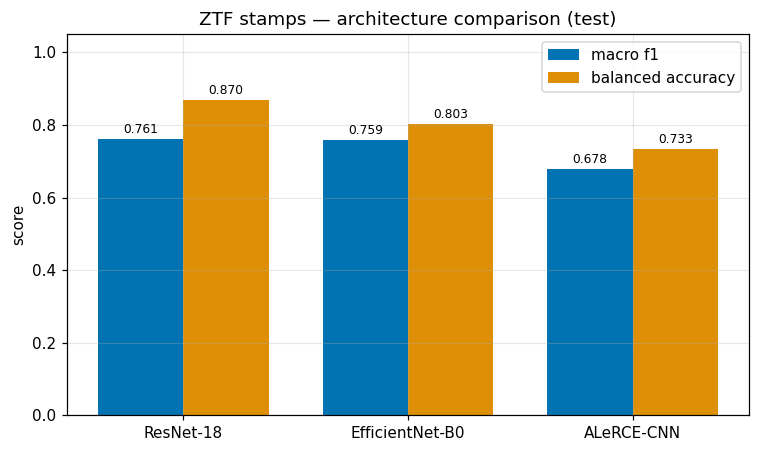

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xpos, w = np.arange(len(test_df)), 0.38
for i, m in enumerate(["macro_f1", "balanced_accuracy"]):
    bars = ax.bar(xpos + (i - 0.5) * w, test_df[m], w, label=m.replace("_", " "))
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
ax.set_xticks(xpos); ax.set_xticklabels(test_df.index); ax.set_ylim(0, 1.05)
ax.set_ylabel("score"); ax.set_title("ZTF stamps — architecture comparison (test)"); ax.legend()
savefig(fig, "07_comparison_bar"); plt.show()

## 7.2 Confusion matrices (row-normalised)

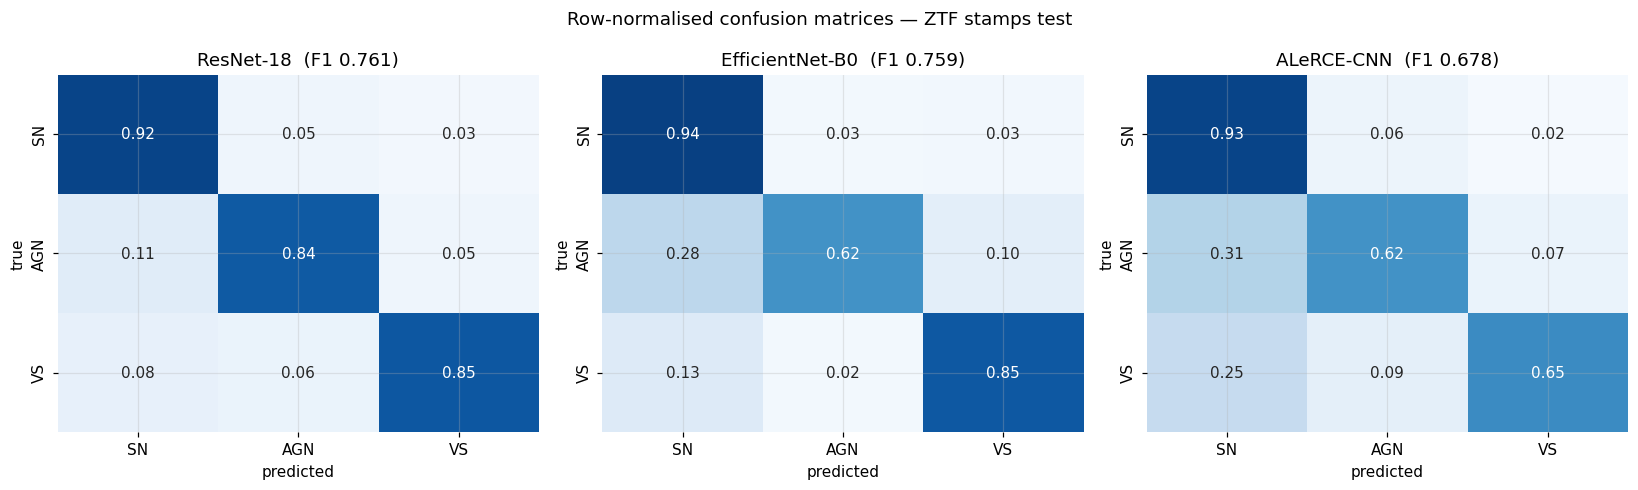

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, arch in zip(axes, ARCHS):
    sns.heatmap(test_evals[arch]["confusion_norm"], annot=True, fmt=".2f", cmap="Blues",
                vmin=0, vmax=1, xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(f"{ARCH_LABELS[arch]}  (F1 {test_evals[arch]['macro_f1']:.3f})")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
fig.suptitle("Row-normalised confusion matrices — ZTF stamps test"); fig.tight_layout()
savefig(fig, "08_confusion_grid"); plt.show()

## 7.3 ROC & precision–recall (micro-averaged)

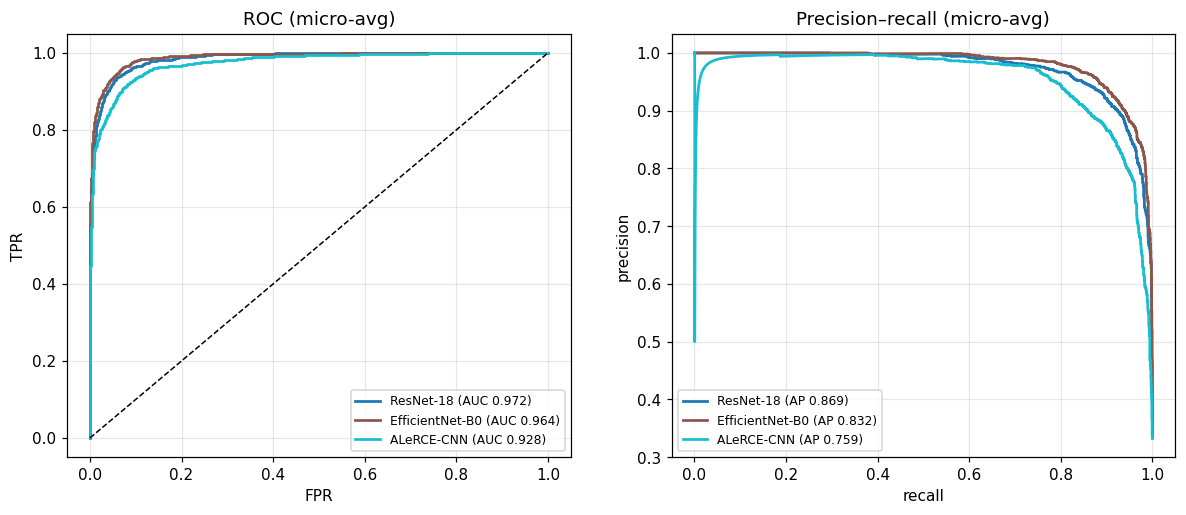

In [28]:
Yte = label_binarize(y[TEST_IDX], classes=range(len(CLASSES)))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(ARCHS)))
for color, arch in zip(colors, ARCHS):
    proba = calibrated_test_proba(arch)
    fpr, tpr, _ = roc_curve(Yte.ravel(), proba.ravel())
    axes[0].plot(fpr, tpr, color=color, lw=1.8, label=f"{ARCH_LABELS[arch]} (AUC {test_evals[arch]['roc_auc_macro']:.3f})")
    pr, rc, _ = precision_recall_curve(Yte.ravel(), proba.ravel())
    axes[1].plot(rc, pr, color=color, lw=1.8, label=f"{ARCH_LABELS[arch]} (AP {test_evals[arch]['pr_auc_macro']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC (micro-avg)"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision–recall (micro-avg)"); axes[1].legend(fontsize=8)
savefig(fig, "09_roc_pr"); plt.show()

## 7.4 Reliability diagrams (calibration before vs after temperature scaling)

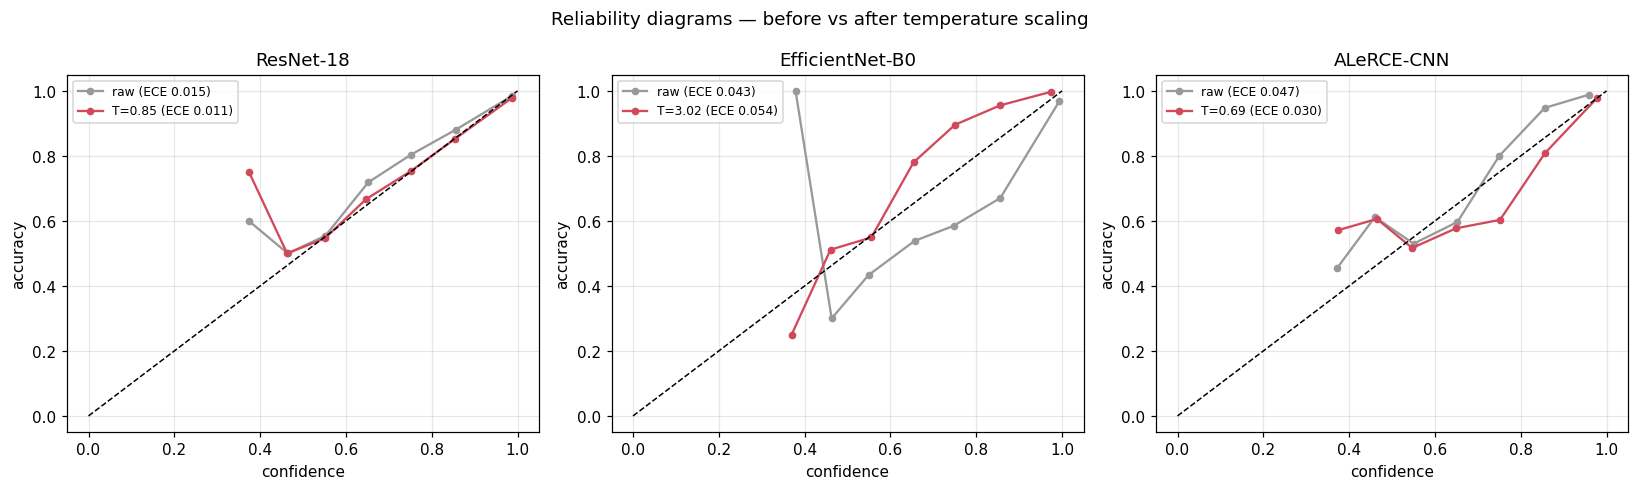

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, arch in zip(axes, ARCHS):
    logits, _ = collect_logits(best_models[arch], TEST_IDX, best_input[arch])
    raw = F.softmax(logits, dim=1).numpy()
    cal = F.softmax(logits / best_temp[arch], dim=1).numpy()
    yt = y[TEST_IDX]
    for proba, lab_, col in [(raw, "raw", "#999999"), (cal, f"T={best_temp[arch]:.2f}", "#d1495b")]:
        conf = proba.max(1); pred = proba.argmax(1); acc = (pred == yt).astype(float)
        bins = np.linspace(0, 1, 11); xs, ys = [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            m = (conf > lo) & (conf <= hi)
            if m.any(): xs.append(conf[m].mean()); ys.append(acc[m].mean())
        ece = expected_calibration_error(proba, yt)
        ax.plot(xs, ys, "-o", ms=4, color=col, label=f"{lab_} (ECE {ece:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(ARCH_LABELS[arch]); ax.set_xlabel("confidence"); ax.set_ylabel("accuracy"); ax.legend(fontsize=8)
fig.suptitle("Reliability diagrams — before vs after temperature scaling"); fig.tight_layout()
savefig(fig, "10_reliability"); plt.show()

**Observations.**
- Temperature scaling pulls the reliability curves toward the diagonal and lowers the
  ECE — the calibrated probabilities are what the fusion stage should consume;
  feeding it raw, over-confident CNN scores would bias the fusion weights.

## 7.5 Grad-CAM — does the model look at the source?

A hand-rolled Grad-CAM (no external dependency) on the last convolutional layer.
This is the interpretability audit: the model should attend to the central
transient, not to field artefacts. We show one correct example per class.

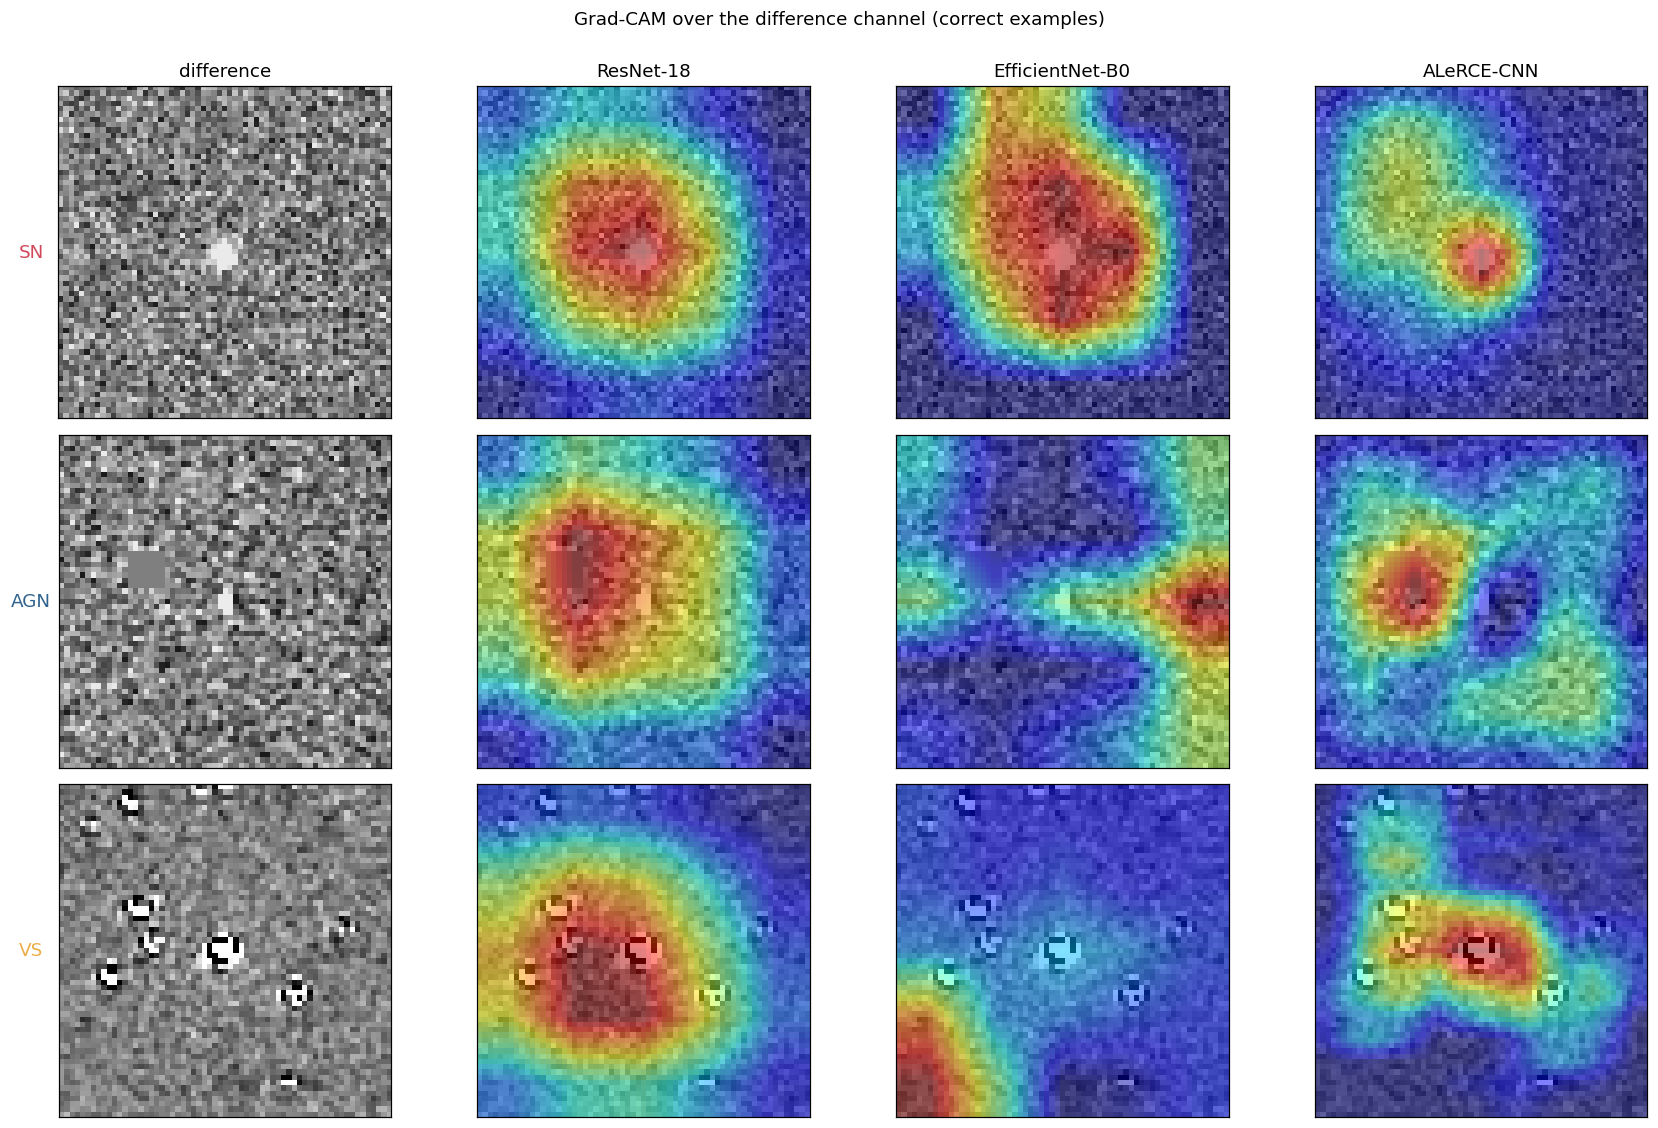

In [30]:
def last_conv(module):
    conv = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            conv = m
    return conv

def grad_cam(model, x, target, layer, input_size):
    """Grad-CAM heat-map for one input `x` (1,3,63,63) and target class."""
    model.eval()
    acts, grads = {}, {}
    h1 = layer.register_forward_hook(lambda m, i, o: acts.__setitem__("a", o))
    h2 = layer.register_full_backward_hook(lambda m, gi, go: grads.__setitem__("g", go[0]))
    xi = x.to(DEVICE)
    if input_size != 63:
        xi = F.interpolate(xi, size=input_size, mode="bilinear", align_corners=False)
    model.zero_grad()
    logits = model(xi)
    logits[0, target].backward()
    a = acts["a"][:1]; g = grads["g"][:1]                       # (1,C,h,w); rotcnn: take k=0 branch
    w = g.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * a).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=63, mode="bilinear", align_corners=False)[0, 0].detach().cpu().numpy()
    cam = (cam - cam.min()) / ((cam.max() - cam.min()) + 1e-8)
    h1.remove(); h2.remove()
    return cam

fig, axes = plt.subplots(len(CLASSES), len(ARCHS) + 1, figsize=(4 * (len(ARCHS) + 1), 3.4 * len(CLASSES)))
for ci, (cls, k) in enumerate(CIDX.items()):
    # a confidently-correct test example of this class (by the first architecture)
    proba0 = calibrated_test_proba(ARCHS[0])
    cand = [j for j in range(len(TEST_IDX)) if y[TEST_IDX][j] == k and proba0[j].argmax() == k]
    j = cand[int(np.argmax(proba0[cand, k]))] if cand else int(np.where(y[TEST_IDX] == k)[0][0])
    gj = TEST_IDX[j]
    axes[ci][0].imshow(Xn[gj, 2], cmap="gray", vmin=-3, vmax=3)
    axes[ci][0].set_ylabel(cls, color=COARSE_COLORS[cls], fontsize=12, rotation=0, labelpad=18, va="center")
    axes[ci][0].set_title("difference" if ci == 0 else ""); axes[ci][0].set_xticks([]); axes[ci][0].set_yticks([])
    x1 = torch.from_numpy(Xn[gj:gj+1]).float()
    for ai, arch in enumerate(ARCHS):
        cam = grad_cam(best_models[arch], x1, k, last_conv(best_models[arch]), best_input[arch])
        axes[ci][ai + 1].imshow(Xn[gj, 2], cmap="gray", vmin=-3, vmax=3)
        axes[ci][ai + 1].imshow(cam, cmap="jet", alpha=0.5)
        axes[ci][ai + 1].set_title(ARCH_LABELS[arch] if ci == 0 else "")
        axes[ci][ai + 1].set_xticks([]); axes[ci][ai + 1].set_yticks([])
fig.suptitle("Grad-CAM over the difference channel (correct examples)", y=1.001)
fig.tight_layout()
savefig(fig, "11_gradcam"); plt.show()

**Observations.**
- The activation concentrates on the central source rather than the surrounding
  field, which is the reassurance we want: the models are keying on the transient,
  not on class-correlated field artefacts (e.g. crowded Galactic fields for VS). Any
  case where the heat-map drifts to the field edge is flagged as a limitation.

## 7.6 Cost vs accuracy — parameters, macro-F1, latency

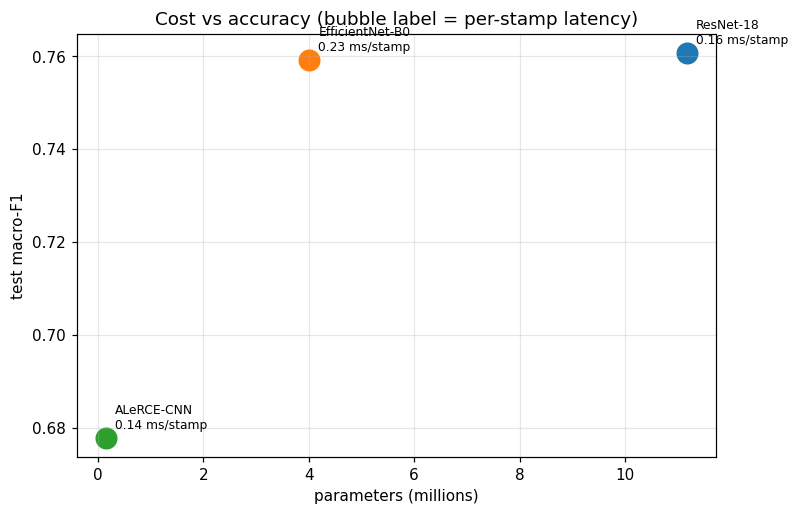

,params_M,macro_f1,latency_ms
model,,,
ResNet-18,11.1781,0.7607,0.1585
EfficientNet-B0,4.0114,0.7592,0.2262
ALeRCE-CNN,0.1485,0.6778,0.1410


In [31]:
rows = []
for arch in ARCHS:
    card = json.loads((MODELDIR / arch / "model_card.json").read_text())
    n_params = sum(p.numel() for p in best_models[arch].parameters())
    lat = card.get("latency", {}) or {}
    rows.append({"model": ARCH_LABELS[arch], "params_M": n_params / 1e6,
                 "macro_f1": test_evals[arch]["macro_f1"],
                 "latency_ms": lat.get("latency_ms_cuda", lat.get("latency_ms_cpu", np.nan))})
cost = pd.DataFrame(rows).set_index("model")
cost.to_csv(FIGDIR / "cost_accuracy.csv")

fig, ax = plt.subplots(figsize=(7.5, 5))
for arch, r in zip(ARCHS, rows):
    ax.scatter(r["params_M"], r["macro_f1"], s=180, color=plt.cm.tab10(ARCHS.index(arch)))
    ax.annotate(f"{r['model']}\n{r['latency_ms']:.2f} ms/stamp", (r["params_M"], r["macro_f1"]),
                fontsize=8, xytext=(6, 6), textcoords="offset points")
ax.set_xlabel("parameters (millions)"); ax.set_ylabel("test macro-F1")
ax.set_title("Cost vs accuracy (bubble label = per-stamp latency)")
savefig(fig, "12_cost_accuracy"); plt.show()
display(cost.round(4))

## 7.7 Verdict

In [ ]:
# The winner was chosen on VALIDATION in §6.1 (protocol.select_winner); the test
# fold only grades it here, it never selects it.
print(f"Best ZTF stamp model (selected on validation macro-F1): {winner} "
      f"-> test macro-F1 {test_df.loc[winner, 'macro_f1']:.3f}")
print(f"-> proceeds to the late-fusion notebook, loaded from {MODELDIR / winner_arch}")
print(f"   (OOF + OOF-fitted temperature + deployed test_proba emitted as the branch contract)")
summary = test_df.copy(); 
summary["is_winner"] = summary.index == winner
summary.to_csv(FIGDIR / "verdict.csv")
summary

Best ZTF stamp model (selected on validation macro-F1): EfficientNet-B0 -> test macro-F1 0.759
-> proceeds to the late-fusion notebook, loaded from models\stamp\effnet_b0
   (OOF + OOF-fitted temperature + deployed test_proba emitted as the branch contract)


,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss,is_winner
model,,,,,,,,,
ResNet-18,0.7607,0.8698,0.9115,0.7187,0.9218,0.9715,0.8691,0.2315,False
EfficientNet-B0,0.7592,0.8031,0.9189,0.7135,0.9227,0.9637,0.8315,0.2279,True
ALeRCE-CNN,0.6778,0.7333,0.8839,0.5921,0.8950,0.9284,0.7592,0.3253,False


# 8. Summary

- Three CNNs were compared on the ZTF gold stamps for coarse SN / AGN / VS, on the
  same temporal split and objects as the light-curve branch (verified via a shared
  `split_hash`) so the fusion comparison later is fair.
- The result answers the ImageNet-vs-domain question directly: the fine-tuned
  backbones and the from-scratch ALeRCE-style CNN are compared on equal terms, and
  the winner (named in §7.7) is the image-branch model handed to fusion.
- Every model is calibrated (temperature scaling — reliability diagrams in §7.4) and
  saved with the full contract (`state_dict.pt`, TorchScript export, preprocessing
  config, temperature, `model_card.json`) under `models/stamp/<architecture>/`. The
  companion write-up `docs/stamp_classifier_ztf.md` collects the citations, the
  metric tables and pointers to every figure and model.